In [5]:
import tensorflow as tf
import numpy as np
import cv2
import matplotlib.pyplot as plt
import os

# set image path (auto-pick first pneumonia image) 
img_path = os.path.join(r"data\chest_xray\test\PNEUMONIA",
                        os.listdir(r"data\chest_xray\test\PNEUMONIA")[0])



In [6]:
#load model
model = tf.keras.models.load_model("xray_model.keras", compile=False)



In [7]:
#  preprocess image 
img = tf.keras.preprocessing.image.load_img(img_path, target_size=(224,224))
img_array = tf.keras.preprocessing.image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)
img_array = tf.keras.applications.efficientnet.preprocess_input(img_array)



In [8]:
#  build connected graph manually
inputs = model.input
x = model.get_layer("sequential_3")(inputs)
feature_maps = model.get_layer("efficientnetb0")(x)
x = model.get_layer("global_average_pooling2d_2")(feature_maps)
x = model.get_layer("dropout_2")(x)
outputs = model.get_layer("dense_2")(x)

grad_model = tf.keras.models.Model(inputs, [feature_maps, outputs])



In [9]:
# Grad-CAM
with tf.GradientTape() as tape:
    conv_outputs, predictions = grad_model(img_array)
    loss = predictions[:, 0]

grads = tape.gradient(loss, conv_outputs)
pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
conv_outputs = conv_outputs[0]
heatmap = conv_outputs @ pooled_grads[..., tf.newaxis]
heatmap = tf.squeeze(heatmap)
heatmap = np.maximum(heatmap, 0) / np.max(heatmap)



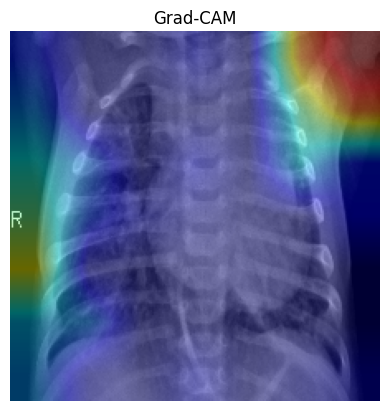

In [10]:
# overlay 
img_raw = cv2.imread(img_path)
img_raw = cv2.resize(img_raw, (224,224))
heatmap = cv2.resize(heatmap, (224,224))
heatmap = np.uint8(255 * heatmap)
heatmap = cv2.applyColorMap(heatmap, cv2.COLORMAP_JET)

overlay = cv2.addWeighted(img_raw, 0.6, heatmap, 0.4, 0)

plt.imshow(cv2.cvtColor(overlay, cv2.COLOR_BGR2RGB))
plt.title("Grad-CAM")
plt.axis("off")
plt.show()